In [47]:
import os, re, json
import pandas as pd
from tqdm import tqdm
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from bs4 import BeautifulSoup
import re

In [48]:

def extract_case_metadata(raw_html):
    """Extract Decision Date, Case No, Bench, Verdict, Judges, and Parties"""
    if not raw_html:
        return None, None, None, None, None, [], None, None

    soup = BeautifulSoup(raw_html, "html.parser")
    text = soup.get_text(" ", strip=True)

    # --- Main details ---
    decision_date = re.search(r"Decision\s*Date\s*[:\-]?\s*([0-9]{1,2}[-/][0-9]{1,2}[-/][0-9]{2,4})", text)
    case_no = re.search(r"Case\s*No\s*[:\-]?\s*([A-Z\s.()0-9/,-]+)", text)
    disposal_nature = re.search(r"Disposal\s*(?:Nature)?\s*[:\-]?\s*([A-Za-z\s&()]+)", text)
    bench_info = re.search(r"Bench\s*[:\-]?\s*([A-Za-z0-9\s]+)", text)
    direction_issue = re.search(r"Direction\s*Issue\s*[:\-]?\s*([A-Za-z\s&()]+)", text)

    decision_date = decision_date.group(1).strip() if decision_date else None
    case_no = case_no.group(1).strip() if case_no else None
    disposal_nature = disposal_nature.group(1).strip() if disposal_nature else None
    bench_info = bench_info.group(1).strip() if bench_info else None
    direction_issue = direction_issue.group(1).strip() if direction_issue else None

    # --- Verdict inference ---
    verdict_label = None
    if disposal_nature:
        if re.search(r"allow|grant|upheld|accepted|partly allow|partly allowed|disposed off|quash", disposal_nature, re.I):
            verdict_label = 1.0
        elif re.search(r"dismiss|refuse|reject|disallow", disposal_nature, re.I):
            verdict_label = 0.0
    elif direction_issue:
        if re.search(r"allow|partly", direction_issue, re.I):
            verdict_label = 1.0
        elif re.search(r"dismiss|refuse", direction_issue, re.I):
            verdict_label = 0.0

    # --- Judges (Coram) ---
    coram_match = re.search(r"Coram\s*[:\-]?\s*([^<]+)", raw_html, flags=re.I)
    judges = []
    if coram_match:
        raw_judge = re.sub(r"<[^>]+>", "", coram_match.group(1))
        raw_judge = re.sub(r"\s+", " ", raw_judge)
        judges = [j.strip() for j in re.split(r",|&|and", raw_judge) if j.strip()]
    bench_size = len(judges) if judges else (int(re.search(r"(\d+)", str(bench_info)).group(1)) if bench_info else 1)

    # --- Parties ---
    party_match = re.search(r"<strong>(.*?)<span.*?versus.*?</span>(.*?)</strong>", raw_html, flags=re.I)
    petitioner = party_match.group(1).strip() if party_match else None
    respondent = party_match.group(2).strip() if party_match else None

    return (
        decision_date,
        case_no,
        bench_info,
        disposal_nature,
        verdict_label,
        judges,
        petitioner,
        respondent,
    )

In [49]:
# =======================================
# 1️⃣ Folder structure
# =======================================
# base_json_dir = os.path.join("My_Datasets", "SC_2020-2025")
# text_dir = "Extracted_Texts"
base_root = r"D:\LPA_MTech_Project"

base_json_dir = os.path.join(base_root, "My_Datasets", "SC_2020-2025")
text_dir      = os.path.join(base_root, "Extracted_Texts", "Texts_2020-2025")

# Dynamically detect all metadata folders under each year
year_folders = []
for year in range(2020, 2026):
    metadata_path = os.path.join(base_json_dir, str(year), "metadata")
    if os.path.exists(metadata_path):
        year_folders.append(metadata_path)

print("Detected metadata folders:")
for folder in year_folders:
    print(" →", folder)

# Collect all JSON files
json_files = []
for year_dir in year_folders:
    for f in os.listdir(year_dir):
        if f.endswith(".json"):
            json_files.append(os.path.join(year_dir, f))

print(f"\n✅ Found {len(json_files)} metadata files across {len(year_folders)} year folders.")

Detected metadata folders:
 → D:\LPA_MTech_Project\My_Datasets\SC_2020-2025\2020\metadata
 → D:\LPA_MTech_Project\My_Datasets\SC_2020-2025\2021\metadata
 → D:\LPA_MTech_Project\My_Datasets\SC_2020-2025\2022\metadata
 → D:\LPA_MTech_Project\My_Datasets\SC_2020-2025\2023\metadata
 → D:\LPA_MTech_Project\My_Datasets\SC_2020-2025\2024\metadata
 → D:\LPA_MTech_Project\My_Datasets\SC_2020-2025\2025\metadata

✅ Found 4370 metadata files across 6 year folders.


In [50]:
# =======================================
# 2️⃣ Load + Merge JSON ↔ Text
# =======================================
records = []

for jfile in tqdm(json_files):
    base = os.path.splitext(os.path.basename(jfile))[0]
    text_path = os.path.join(text_dir, base + "_EN.txt")

    if not os.path.exists(text_path):
        continue  # skip missing

    try:
        with open(jfile, "r", encoding="utf-8") as jf:
            meta = json.load(jf)
        with open(text_path, "r", encoding="utf-8") as tf:
            text = tf.read()

        raw_html = meta.get("raw_html", "")
        year = meta.get("citation_year")

        # --- Extract structured metadata using the universal parser ---
        (
            decision_date,
            case_no,
            bench_info,
            disposal_nature,
            verdict_label,
            judges,
            petitioner,
            respondent
        ) = extract_case_metadata(raw_html)

        # --- Compute bench size safely ---
        bench_size = len(judges) if judges else (int(re.search(r"(\d+)", str(bench_info)).group(1)) if bench_info and re.search(r"\d+", bench_info) else 1)

        record = {
            "case_id": meta.get("path", base),
            "year": int(year) if year else None,
            "decision_date": decision_date,
            "case_no": case_no,
            "bench_info": bench_info,
            "bench_size": bench_size,
            "judges": judges,
            "petitioner": petitioner,
            "respondent": respondent,
            "disposal_nature": disposal_nature,
            "verdict_label": verdict_label,
            "raw_html": raw_html,
            "text": text
        }

        records.append(record)

    except Exception as e:
        print(f"⚠️ Error reading {jfile}: {e}")

df = pd.DataFrame(records)
print("✅ Records loaded:", len(df))
print("Columns:", df.columns.tolist())


 66%|██████▌   | 2888/4370 [01:45<00:50, 29.56it/s]

⚠️ Error reading D:\LPA_MTech_Project\My_Datasets\SC_2020-2025\2023\metadata\2023_3_644_648.json: 'NoneType' object has no attribute 'group'


100%|██████████| 4370/4370 [02:45<00:00, 26.40it/s]


✅ Records loaded: 4367
Columns: ['case_id', 'year', 'decision_date', 'case_no', 'bench_info', 'bench_size', 'judges', 'petitioner', 'respondent', 'disposal_nature', 'verdict_label', 'raw_html', 'text']


In [51]:
# =======================================
# 3️⃣ Feature Enrichment
# =======================================
df = df.dropna(subset=["text"])
df["year"] = pd.to_numeric(df.get("year", 0)).fillna(0).astype(int)
df["decade"] = (df["year"] // 10) * 10

# ---- Structural ----
df["num_words_text"] = df["text"].apply(lambda x: len(str(x).split()))
df["num_lines"] = df["text"].apply(lambda x: len(str(x).splitlines()))

# ---- Legal Signals ----
def extract_act_names(text):
    return re.findall(r'([A-Z][A-Za-z\s]+Act[, ]\s*\d{4})', str(text))




In [52]:
def _is_likely_money_or_para(context):
    """Return True if context suggests the match is monetary, a paragraph/clause, or installment."""
    # common words that indicate non-IPC numeric contexts
    reject_tokens = [
        "rs", "₹", "rs.", "crore", "crores", "lakh", "lakhs",
        "para", "paragraph", "clause", "instal", "install", "instalment",
        "scheme", "n i a", "nia", "bank guarantee", "guarantee",
        "page", "pp.", "pp ", "order dated", "dated", "fig", "nos."
    ]
    ctx = context.lower()
    for t in reject_tokens:
        if t in ctx:
            return True
    # also reject if a currency symbol appears
    if re.search(r'[\d\.,]+\s*(crore|lakh|rs|₹)', ctx):
        return True
    return False


def _clean_and_validate_section(sec_str, match_span, text):
    """
    Normalise a matched section token (like '302A' or '302') and validate:
    - numeric part must be 1..511 (IPC range)
    - nearby context must contain 'IPC' / 'Indian Penal Code' (within ~50 chars)
    - not in a money/para/clause context
    Returns normalized string (e.g. '302A') or None if rejected.
    """
    sec_str = sec_str.strip()
    num_part_match = re.search(r'(\d+)', sec_str)
    if not num_part_match:
        return None
    num = int(num_part_match.group(1))
    if not (1 <= num <= 511):
        return None

    # context window to check for 'IPC' and reject money/para contexts
    start, end = match_span
    ctx_start = max(0, start - 60)
    ctx_end = min(len(text), end + 60)
    context = text[ctx_start:ctx_end]

    # require explicit IPC mention in nearby context (to avoid "s. 774" etc.)
    if not (re.search(r'\bipc\b', context, flags=re.I) or re.search(r'indian penal code', context, flags=re.I)):
        return None

    # reject if context looks monetary or clause-like
    if _is_likely_money_or_para(context):
        return None

    # OK — return normalized (preserve letter suffix if present, e.g. '498A')
    suffix = re.search(r'[A-Za-z]+$', sec_str)
    if suffix:
        return f"{num}{suffix.group(0).upper()}"
    return str(num)


def extract_ipc_mentions(text):
    """
    Improved replacement for the original `extract_ipc_mentions`.
    Returns a list of validated IPC section strings found in the text,
    e.g. ['302', '420', '498A'].
    """
    if not isinstance(text, str):
        return []

    results = []
    # common surface forms: "Section 302", "Sec. 302", "s.302", "u/s 498A"
    pattern = r"(?:Section|Sec\.|Sec|s\.|s|u/s|u/s\.)\s*([0-9]{1,3}[A-Za-z]?)\b"
    for m in re.finditer(pattern, text, flags=re.I):
        sec_token = m.group(1)
        validated = _clean_and_validate_section(sec_token, m.span(), text)
        if validated:
            results.append(validated)

    # deduplicate and return
    return list(dict.fromkeys(results))


def extract_additional_ipc_mentions(text):
    """
    Additional detection that captures forms like '302 IPC', '302 I.P.C.', or
    'Section 302 of the Indian Penal Code' where the number appears immediately
    followed or preceded by 'IPC'. This is stricter and complementary.
    """
    if not isinstance(text, str):
        return []

    results = []
    # pattern to catch forms where number and 'IPC' are adjacent: "302 IPC", "302 I.P.C.", "302 of the Indian Penal Code"
    pattern = r"\b([0-9]{1,3}[A-Za-z]?)\s*(?:I\.P\.C\.|IPC|Indian\s+Penal\s+Code)\b|\b(?:I\.P\.C\.|IPC|Indian\s+Penal\s+Code)\b\s*(?:of\s*)?\s*([0-9]{1,3}[A-Za-z]?)\b"
    for m in re.finditer(pattern, text, flags=re.I):
        sec_token = m.group(1) if m.group(1) else (m.group(2) if m.group(2) else None)
        if not sec_token:
            continue
        # create a fake span around the match for context checks
        start, end = m.span()
        validated = _clean_and_validate_section(sec_token, (start, end), text)
        if validated:
            results.append(validated)

    return list(dict.fromkeys(results))

In [53]:
#  ===== Apply to dataframe (keeps same downstream columns) =====
# Replace previous assignments for ipc detection with the following:


# Merge without double-counting: union of both lists
def _union_lists(a, b):
    a = a or []
    b = b or []
    seen = {}
    out = []
    for item in a + b:
        key = item.upper()
        if key not in seen:
            seen[key] = True
            out.append(item)
    return out

In [54]:
df["act_names"] = df["text"].apply(extract_act_names)
df["ipc_mentions"] = df["text"].apply(extract_ipc_mentions)
df["ipc_mentions_extra"] = df["text"].apply(extract_additional_ipc_mentions)
df["ipc_sections"] = df.apply(lambda r: _union_lists(r["ipc_mentions"], r["ipc_mentions_extra"]), axis=1)
df["num_ipc_refs"] = df["ipc_sections"].apply(len)
df["has_ipc"] = (df["num_ipc_refs"] > 0).astype(int)
df["ipc_mentions"] = df["ipc_sections"]  

df["num_unique_acts"] = df["act_names"].apply(lambda x: len(set(x)))

# Print quick stats (similar to prior message)
total_cases = len(df)
cases_with_ipc = df["has_ipc"].sum()
print(f"✅ IPC detection refined: {cases_with_ipc}/{total_cases} cases ({cases_with_ipc/total_cases*100:.2f}%) now flagged as having IPC sections.")


✅ IPC detection refined: 1145/4367 cases (26.22%) now flagged as having IPC sections.


In [55]:
# ---- Sentiment + Context ----
pos_words = ["granted", "allowed", "favour", "upheld", "entitled"]
neg_words = ["dismissed", "rejected", "refused", "denied", "not maintainable"]
df["sentiment_score"] = df["text"].apply(lambda t: sum(w in t.lower() for w in pos_words) - sum(w in t.lower() for w in neg_words))
df["petitioner_mentions"] = df["text"].str.count(r"(?i)petitioner")
df["respondent_mentions"] = df["text"].str.count(r"(?i)respondent")
df["pet_vs_resp_ratio"] = df.apply(lambda r: (r["petitioner_mentions"] + 1)/(r["respondent_mentions"] + 1), axis=1)


In [56]:
# ---- Keyword extraction ----
def extract_keywords(text, top_n=10):
    words = re.findall(r'\b[a-zA-Z]{4,}\b', str(text).lower())
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    common = [w for w, _ in Counter(words).most_common(top_n)]
    return common

df["keywords"] = df["text"].apply(lambda x: extract_keywords(x, 10))


In [57]:
# ---- Case type inference ----
def infer_case_type(text):
    t = str(text).lower()
    if "criminal" in t: return "Criminal"
    if "civil" in t: return "Civil"
    if "tax" in t or "income tax" in t: return "Tax"
    if "constitution" in t: return "Constitutional"
    if "labour" in t or "industrial" in t: return "Labour"
    return "Other"

df["case_type"] = df["text"].apply(infer_case_type)


In [58]:
# ---- Citations ----
def extract_citations(text):
    return re.findall(r'\(\d{4}\)\s*\d+\s*SCC\s*\d+|AIR\s*\d{4}\s*SC\s*\d+|\[\d{4}\]\s*\d+\s*SCR\s*\d+', str(text))

df["citations"] = df["text"].apply(extract_citations)
df["num_citations"] = df["citations"].apply(len)


In [59]:
# ---- Constitution Articles ----
def extract_constitution_articles(text):
    return re.findall(r'Article\s*\d+[A-Za-z0-9]*', str(text), flags=re.I)

df["constitution_articles"] = df["text"].apply(extract_constitution_articles)
df["has_constitution_article"] = df["constitution_articles"].apply(lambda x: 1 if len(x) > 0 else 0)


In [60]:
# =======================================
# 4️⃣ Save enriched parquet
# =======================================
out_path = "SupremeCourt_Combined_2020_2025_enriched.parquet"
df.to_parquet(out_path, index=False)
print(f"✅ Enriched dataset saved: {out_path} — shape: {df.shape}")

✅ Enriched dataset saved: SupremeCourt_Combined_2020_2025_enriched.parquet — shape: (4367, 33)


Dataset Quality Visualizer

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
# =======================================
# 1️⃣ Load dataset
# =======================================
df = pd.read_parquet("SupremeCourt_Combined_2020_2025_enriched.parquet")
print(f"✅ Loaded {len(df)} records with {df.shape[1]} columns")


✅ Loaded 4367 records with 33 columns



--- Missing Values (Top 15) ---
verdict_label      7.01
disposal_nature    3.30
case_id            0.00
year               0.00
decision_date      0.00
bench_size         0.00
judges             0.00
case_no            0.00
bench_info         0.00
respondent         0.00
petitioner         0.00
raw_html           0.00
text               0.00
decade             0.00
num_words_text     0.00
dtype: float64


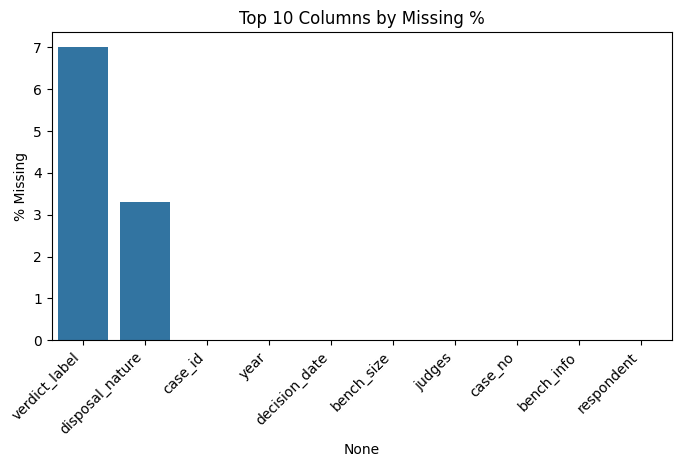

In [63]:
# =======================================
# 2️⃣ Missing value audit
# =======================================
print("\n--- Missing Values (Top 15) ---")
missing = df.isnull().mean().sort_values(ascending=False) * 100
print(missing.head(15).round(2))

plt.figure(figsize=(8,4))
sns.barplot(x=missing.head(10).index, y=missing.head(10).values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Columns by Missing %")
plt.ylabel("% Missing")
plt.show()


--- Verdict Label Distribution ---
verdict_label
1.0    3055
0.0    1006
NaN     306
Name: count, dtype: int64


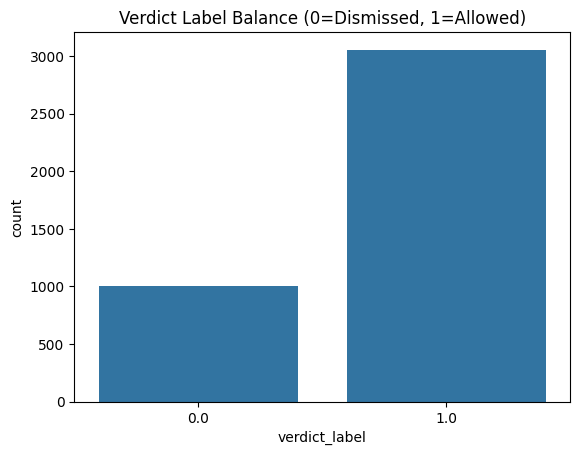

In [64]:
# =======================================
# 3️⃣ Data completeness & label balance
# =======================================
print("\n--- Verdict Label Distribution ---")
print(df['verdict_label'].value_counts(dropna=False))
sns.countplot(x='verdict_label', data=df)
plt.title("Verdict Label Balance (0=Dismissed, 1=Allowed)")
plt.show()


--- Text Length Stats ---
count      4367.00
mean       8648.86
std       11493.52
min         183.00
25%        3321.50
50%        5457.00
75%        9406.00
max      150429.00
Name: text_len, dtype: float64


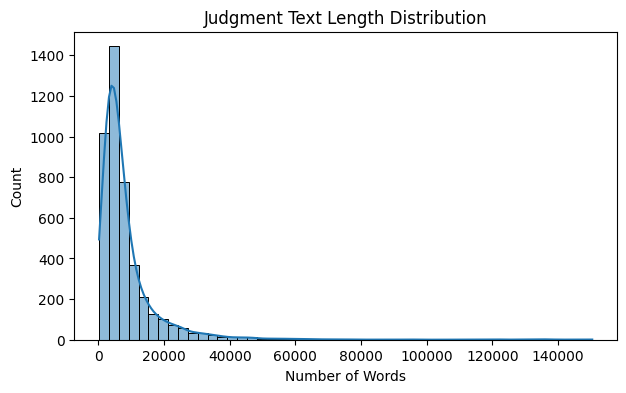

In [65]:
# =======================================
# 4️⃣ Text quality metrics
# =======================================
print("\n--- Text Length Stats ---")
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))
print(df['text_len'].describe().round(2))

plt.figure(figsize=(7,4))
sns.histplot(df['text_len'], bins=50, kde=True)
plt.title("Judgment Text Length Distribution")
plt.xlabel("Number of Words")
plt.show()

In [66]:
# =======================================
# 5️⃣ Feature richness audit
# =======================================
print("\n--- Bench & Case Type ---")
print("Average bench size:", round(df['bench_size'].mean(), 2))
print("\nCase type distribution:\n", df['case_type'].value_counts(normalize=True).mul(100).round(1))

print("\nHas IPC references:", df['has_ipc'].sum(), "/", len(df))
print("Has Constitution Articles:", df['has_constitution_article'].sum(), "/", len(df))



--- Bench & Case Type ---
Average bench size: 1.14

Case type distribution:
 case_type
Civil             58.4
Criminal          41.5
Other              0.1
Constitutional     0.0
Tax                0.0
Name: proportion, dtype: float64

Has IPC references: 1145 / 4367
Has Constitution Articles: 2139 / 4367


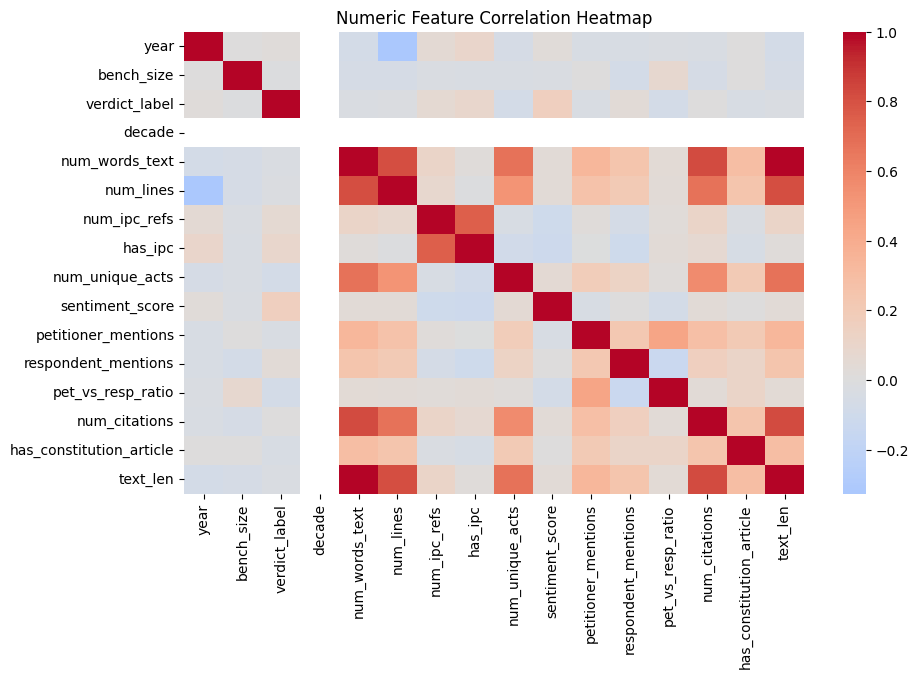

In [67]:
# =======================================
# 6️⃣ Correlation between numeric features
# =======================================
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation Heatmap")
plt.show()

In [68]:
# =======================================
# 7️⃣ Quick semantic sanity: top frequent Acts & Articles
# =======================================
acts = df['act_names'].explode().dropna().value_counts().head(10)
articles = df['constitution_articles'].explode().dropna().value_counts().head(10)

print("\n--- Top 10 Most Frequent Acts ---\n", acts)
print("\n--- Top 10 Constitution Articles ---\n", articles)


--- Top 10 Most Frequent Acts ---
 act_names
Arbitration and Conciliation Act, 1996    655
Limitation Act, 1963                      598
Evidence Act, 1872                        511
Land Acquisition Act, 1894                441
Companies Act, 2013                       436
Arbitration Act, 1996                     390
Companies Act, 1956                       380
Income Tax Act, 1961                      334
Consumer Protection Act, 1986             294
Transfer of Property Act, 1882            292
Name: count, dtype: int64

--- Top 10 Constitution Articles ---
 constitution_articles
Article 14     2592
Article 226    2349
Article 21     1779
Article 19     1583
Article 16     1530
Article 142    1340
Article 32     1288
Article 30     1044
Article 136     941
Article 370     910
Name: count, dtype: int64
